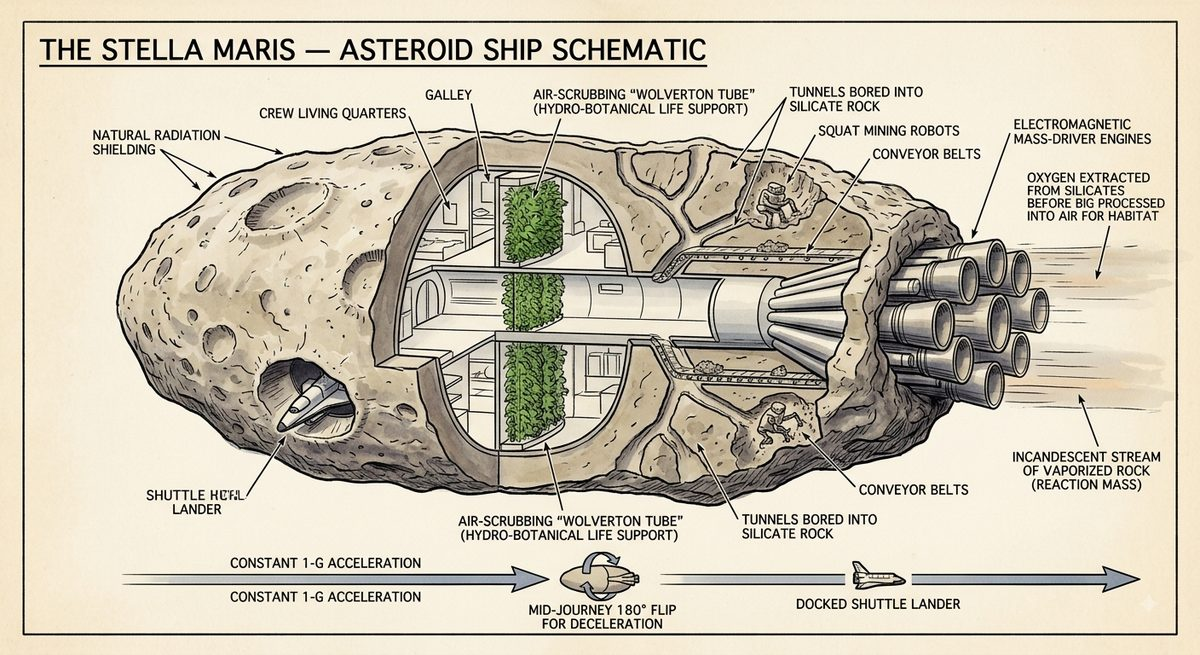


De Stella Maris vliegt naar Alpha Centauri. Er is aan boord normale zwaartekracht omdat ze gedurende de dag met 1 g versnellen.
Tijdens het slapen versnellen ze zelfs met 2 g. Halverwege draait het schip om en remt het met 1 g af.

Cool idee maar er klopt geen hout van de getallen.

| Bewering                                | Waarde                                |
| --------------------------------------- | ------------------------------------- |
| Reistijd in het aardframe (enkele reis) | **17 jaar**                           |
| Scheepstijd (subjectief)                | **~6–7 maanden**                      |
| Topsnelheid                             | **0.93 c**, bereikt "binnen een jaar" |
| Tijddilatatie op het hoogtepunt         | **3 scheepsdagen per aardjaar**       |

Hoe dom is het allemaal? Let's find out.


## 1 · Eenheden en constanten

Eenheden voor interstellair reizen: afstanden in lichtjaren, tijden in jaren, dus $c = 1\ \mathrm{lj/jr}$.

$$1\,g = 9.80665\ \mathrm{m/s^2} = 1.0323\ \mathrm{lj/jr^2}$$

Met andere woorden: 1 g, ongeveer een jaar volgehouden, brengt je tot ongeveer de
lichtsnelheid (voordat de relativiteit ingrijpt).

Afstand: **Alpha Centauri A/B op 4.37 lj**


### Zonder relativiteit:

1. **Opstarten:** met 1 g ≈ 1 lj/jr² zit je na ~1 jaar op ~c. Maar je gemiddelde snelheid
   in dat jaar is maar ~½c, dus je legt slechts **~½ lj** af.
2. **Afremmen:** nog ~½ lj (spiegelbeeld).
3. **Cruisen:** blijft over 4.37 − 1 ≈ 3.4 lj op ~c → **~3.4 jaar**

Totaal ≈ 1 + 3.4 + 1 ≈ **5.4 jaar**.


### Met relativiteit:

Wat bij constante 1 g écht lineair groeit is niet de snelheid maar de **impuls** (per kg
massa): $\gamma\beta = at/c$. De snelheid is die impuls gedeeld door de lorentzfactor
$\gamma = \sqrt{1 + (at/c)^2}$ die je onderweg opbouwt:

$$\beta(t) = \frac{at/c}{\sqrt{1 + (at/c)^2}}
\qquad\Rightarrow\qquad
\beta(1\,\mathrm{jr}) = \frac{1.03}{\sqrt{1 + 1.03^2}} = \frac{1.03}{1.44} \approx 0.72$$

De factor die het Newtoniaanse "~c na 1 jaar" terugbrengt naar 0.72 c is dus
$1/\gamma \approx 1/1.44$. Relativiteit remt al vanaf ~½c, niet pas vlak onder c:

| aardtijd op 1 g | 1 jr | 2 jr | 3 jr | 5 jr |
|---|---|---|---|---|
| snelheid | 0.72 c | 0.90 c | 0.95 c | 0.98 c |

De ramps duren dus langer dan het Newtoniaanse jaar — dát is het gat tussen de envelope
(5.4 jr) en het exacte antwoord van §3: **6.0 aardjaar**. En voor de **scheepstijd** is er
een verrassend exacte shortcut via de rapiditeit:
$\tau = 2\,\mathrm{artanh}(\beta_\mathrm{piek})/g = 2 \cdot 1.85 / 1.03 \approx$ **3.6 jaar**.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

C = 1.0  # lichtsnelheid, lj/jr
G = 1.0323  # 1 g uitgedrukt in lj/jr^2
D = 4.37  # afstand tot Alpha Centauri A/B, lj

print(f"Reistijd van licht naar het doel (absolute ondergrens): {D / C:.2f} jr")

Reistijd van licht naar het doel (absolute ondergrens): 4.37 jr


## 2 · Kinematica van constante eigenversnelling

"Constant 1 g" betekent constante **eigen**versnelling $a$ — wat de personenweegschaal van
de bemanning aanwijst. In het aardframe levert dit _hyperbolische beweging_ op. Met $t$ =
aardtijd (coördinaattijd) en $\tau$ = scheepstijd (eigentijd) zijn de gesloten oplossingen:

$$
\gamma(t) = \sqrt{1 + \left(\frac{at}{c}\right)^2}, \qquad
\beta(t) = \frac{at/c}{\gamma(t)}, \qquad
x(t) = \frac{c^2}{a}\left(\gamma(t) - 1\right), \qquad
\tau(t) = \frac{c}{a}\,\mathrm{asinh}\!\left(\frac{at}{c}\right)
$$

Let op de asymptotiek: $\beta \to 1$ maar bereikt het nooit, terwijl $\gamma$ en $x$
onbegrensd groeien. De scheepsklok $\tau$ groeit slechts _logaritmisch_ in $t$ — dáár zit
de tijddilatatie.

**Flip-and-burn:** versnel over de eerste helft van de afstand $D/2$, draai het schip 180°,
rem af over de tweede helft. Door symmetrie is de remfase het spiegelbeeld van de
versnellingsfase, dus we hebben alleen de oplossing van fase 1 en een spiegeling nodig.
De topsnelheid en de maximale $\gamma$ vallen precies op het middelpunt:

$$\gamma_{\max} = 1 + \frac{aD}{2c^2}$$


In [ ]:
def phase(a, t):
    """Toestand na aardtijd t bij constante eigenversnelling a (vanuit stilstand)."""
    at = a * t / C
    gamma = np.sqrt(1.0 + at**2)
    beta = at / gamma
    x = (C**2 / a) * (gamma - 1.0)
    tau = (C / a) * np.arcsinh(at)
    return beta, gamma, x, tau


def brachistochrone(a, D, n=4000):
    """Versnel tot het middelpunt, draai om, rem af. Geeft aardframe-arrays + samenvatting."""
    x_half = D / 2.0
    t_half = (C / a) * np.sqrt((1.0 + a * x_half / C**2) ** 2 - 1.0)
    tau_half = (C / a) * np.arccosh(1.0 + a * x_half / C**2)

    t = np.linspace(0.0, 2.0 * t_half, n)
    beta, gamma, x, tau = (np.empty_like(t) for _ in range(4))

    first = t <= t_half
    beta[first], gamma[first], x[first], tau[first] = phase(a, t[first])

    tr = 2.0 * t_half - t[~first]  # resterende tijd tot aankomst
    b2, g2, x2, tau2 = phase(a, tr)  # spiegelbeeld van de boostfase
    beta[~first], gamma[~first] = b2, g2
    x[~first] = D - x2
    tau[~first] = 2.0 * tau_half - tau2

    summary = {
        "a_g": a / G,
        "t_total": 2 * t_half,
        "tau_total": 2 * tau_half,
        "beta_max": phase(a, t_half)[0],
        "gamma_max": phase(a, t_half)[1],
    }
    return t, beta, gamma, x, tau, summary

## 3 · Twee vluchtprofielen

**Profiel A — zuiver 1 g**, de brachistochroon uit het leerboek.

**Profiel B — het schema uit de roman**: 16 u/dag op 1 g plus 8 u/dag op 2 g terwijl de
bemanning slaapt. Tijdgemiddeld is dat

$$\bar a = \frac{16 \cdot 1 + 8 \cdot 2}{24}\,g = \tfrac{4}{3}\,g \approx 1.33\,g$$

(Strikt genomen zou er in eigentijd gemiddeld moeten worden en zou de dagelijkse modulatie
geïntegreerd moeten worden, maar over een reis van meerdere jaren is de fout van de
constante-$\bar a$-benadering verwaarloosbaar — veel kleiner dan de discrepanties die we
zo gaan vinden.)


In [ ]:
scenarios = {
    "A: 1 g flip-and-burn": brachistochrone(1.00 * G, D),
    "B: schema uit het boek (~1.33 g gem.)": brachistochrone(4.0 / 3.0 * G, D),
}

for name, (_t, _b, _g, _x, _tau, s) in scenarios.items():
    print(name)
    print(f"   Aardtijd    (enkele reis): {s['t_total']:.2f} jr")
    print(f"   Scheepstijd (enkele reis): {s['tau_total']:.2f} jr")
    print(f"   Topsnelheid:               {s['beta_max']:.4f} c")
    print(f"   Maximale gamma:            {s['gamma_max']:.2f}")
    print(f"   Scheepsdagen per aardjaar op het hoogtepunt: {365.25 / s['gamma_max']:.0f}")
    print()

A: 1 g flip-and-burn
   Aardtijd    (enkele reis): 6.00 jr
   Scheepstijd (enkele reis): 3.58 jr
   Topsnelheid:               0.9517 c
   Maximale gamma:            3.26
   Scheepsdagen per aardjaar op het hoogtepunt: 112

B: schema uit het boek (~1.33 g gem.)
   Aardtijd    (enkele reis): 5.64 jr
   Scheepstijd (enkele reis): 3.00 jr
   Topsnelheid:               0.9684 c
   Maximale gamma:            4.01
   Scheepsdagen per aardjaar op het hoogtepunt: 91



Het _juiste_ antwoord voor het traject dat het boek beschrijft is dus ruwweg
**5.6–6 aardjaren** en **3–3.6 scheepsjaren**, met een piek rond **0.95–0.97 c** en
$\gamma_{\max} \approx 3\!-\!4$. Opvallend: de 0.93 c uit het boek ligt _dicht bij_ het
echte 1 g-antwoord — de snelheid is ooit correct uitgerekend. De tijdlijnen niet.


## 4 · De beweringen uit het boek in kruisverhoor

De drie kerngetallen impliceren drie **onderling onverenigbare** lorentzfactoren:

1. **17 aardjaren met ~6.5 scheepsmaanden** vereist gemiddeld
   $\langle\gamma\rangle = \dfrac{17}{0.55} \approx 31$.
2. **17 aardjaren over 4.37 lj** betekent een gemiddelde snelheid van slechts
   $\langle\beta\rangle = 4.37/17 \approx 0.26\,c$, wat $\gamma \approx 1.03$ geeft —
   vrijwel _geen_ tijddilatatie.
3. **"Drie scheepsdagen per aardjaar"** vereist $\gamma = 365.25/3 \approx 122$,
   oftewel $\beta = 0.999966\,c$ — terwijl de genoemde **0.93 c** slechts $\gamma = 2.72$
   geeft, oftewel **134** scheepsdagen per aardjaar. Een factor ~45 ernaast.

Geen enkel traject langs een directe route voldoet aan twee van deze beweringen tegelijk.
(Pedante uitvlucht: een schip dat 17 jaar lang met $\gamma = 122$ rondjes in de buurt draait
_zou_ 7 weken verouderen — maar dat is geen flip-and-burn, en de energierekening wordt nóg
absurder.) De fouten wijzen bovendien in _tegengestelde_ richtingen: de aardklok loopt te
langzaam en de scheepsklok te snel.


In [ ]:
print("gamma impliciet in 17 jr / 6.5 maanden:", f"{17 / 0.55:.1f}")

beta_avg = D / 17
print(
    "beta impliciet in 17 jr reistijd:      ",
    f"{beta_avg:.3f} c -> gamma = {1 / np.sqrt(1 - beta_avg**2):.3f}",
)

print(
    "gamma nodig voor 3 dagen/aardjaar:     ",
    f"{365.25 / 3:.1f} -> beta = {np.sqrt(1 - (3 / 365.25) ** 2):.6f} c",
)

g093 = 1 / np.sqrt(1 - 0.93**2)
print(
    "gamma bij de genoemde 0.93 c:          ",
    f"{g093:.2f} -> {365.25 / g093:.0f} scheepsdagen per aardjaar",
)

# En de bewering dat 0.93 c "binnen een jaar" wordt gehaald:
print()
print("Versnelling nodig om 0.93 c binnen één jaar te bereiken:")
print(f"   volgens de scheepsklok: {np.arctanh(0.93) / G:.2f} g continu")
print(f"   volgens de aardklok:    {0.93 * g093 / G:.2f} g continu")

gamma impliciet in 17 jr / 6.5 maanden: 30.9
beta impliciet in 17 jr reistijd:       0.257 c -> gamma = 1.035
gamma nodig voor 3 dagen/aardjaar:      121.8 -> beta = 0.999966 c
gamma bij de genoemde 0.93 c:           2.72 -> 134 scheepsdagen per aardjaar

Versnelling nodig om 0.93 c binnen één jaar te bereiken:
   volgens de scheepsklok: 1.61 g continu
   volgens de aardklok:    2.45 g continu


De bewering "binnen een jaar naar 0.93 c" vereist **1.6–2.5 g volgehouden**, niet de
beschreven dagen op 1 g. En kijk wat het 2 g-slaapschema werkelijk oplevert: vergelijk
profielen A en B hierboven — het scheelt ~0.4 aardjaren en ~0.6 scheepsjaren, een verbetering
van ~10 %, in ruil voor een verdubbelde cardiovasculaire belasting voor elk bemanningslid,
acht uur per nacht, een jaar lang. Proefpersonen in centrifuges verdragen 2 g liggend
urenlang; niemand heeft het maandenlang elke nacht gedaan.


## 5 · Het traject in beeld

Vier aanzichten van de reis: snelheid, lorentzfactor, afgelegde afstand, en de scheepsklok
tegenover de aardklok. De beweringen uit de roman zijn ter contrast gemarkeerd — zie hoe ver
het kruisje "aankomst na 17 jr" en de lijn $\gamma = 122$ van al het fysische af liggen.


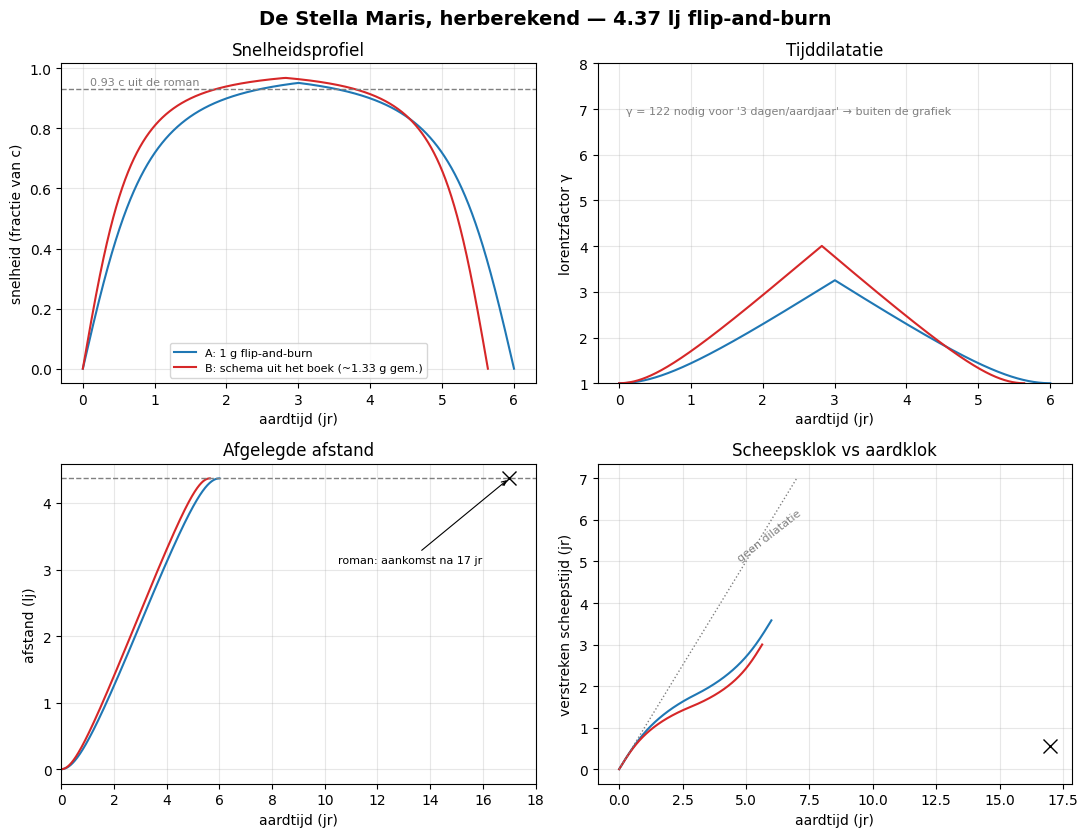

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
fig.suptitle("De Stella Maris, herberekend — 4.37 lj flip-and-burn", fontsize=14, fontweight="bold")
colors = {"A: 1 g flip-and-burn": "#1f77b4", "B: schema uit het boek (~1.33 g gem.)": "#d62728"}

for name, (t, b, g, x, tau, _s) in scenarios.items():
    c = colors[name]
    axes[0, 0].plot(t, b, color=c, label=name)
    axes[0, 1].plot(t, g, color=c)
    axes[1, 0].plot(t, x, color=c)
    axes[1, 1].plot(t, tau, color=c)

ax = axes[0, 0]
ax.axhline(0.93, ls="--", lw=1, color="gray")
ax.text(0.1, 0.945, "0.93 c uit de roman", fontsize=8, color="gray")
ax.set(xlabel="aardtijd (jr)", ylabel="snelheid (fractie van c)", title="Snelheidsprofiel")
ax.legend(fontsize=8, loc="lower center")

ax = axes[0, 1]
ax.axhline(122, ls=":", lw=1, color="gray")
ax.text(
    0.1, 6.9, "γ = 122 nodig voor '3 dagen/aardjaar' → buiten de grafiek", fontsize=8, color="gray"
)
ax.set(xlabel="aardtijd (jr)", ylabel="lorentzfactor γ", title="Tijddilatatie", ylim=(1, 8))

ax = axes[1, 0]
ax.axhline(D, ls="--", lw=1, color="gray")
ax.plot(17, D, "kx", ms=10)
ax.annotate(
    "roman: aankomst na 17 jr",
    (17, D),
    (10.5, 3.1),
    fontsize=8,
    arrowprops={"arrowstyle": "->", "lw": 0.8},
)
ax.set(xlabel="aardtijd (jr)", ylabel="afstand (lj)", title="Afgelegde afstand", xlim=(0, 18))

ax = axes[1, 1]
ax.plot([0, 7], [0, 7], ls=":", lw=1, color="gray")
ax.text(4.6, 5.0, "geen dilatatie", fontsize=8, color="gray", rotation=38)
ax.plot(17, 0.55, "kx", ms=10, clip_on=False)
ax.set(
    xlabel="aardtijd (jr)", ylabel="verstreken scheepstijd (jr)", title="Scheepsklok vs aardklok"
)

for a in axes.flat:
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 6 · De raketvergelijking (dit is het genadeschot)

De kinematica hierboven nam aan dat _een of andere_ motor 1 g kan volhouden. Het boek
specificeert de motor: **mass drivers** die vergruisde asteroïdesilicaten elektromagnetisch
wegslingeren. Mass drivers zijn echte technologie — voorgesteld voor lanceringen vanaf de
maan, met uitstroomsnelheden van ~2–3 km/s. Wees gul en gun ze **30 km/s**.

De relativistische Tsiolkovski-vergelijking voor het bereiken van snelheid $\beta$ met
uitstroomsnelheid $v_e$:

$$\frac{M_0}{M_1} = \exp\!\left(\frac{c\,\mathrm{artanh}(\beta)}{v_e}\right)$$

De exponent is de _rapiditeit_ maal $c/v_e$. Met $\beta = 0.95$ en $v_e = 30$ km/s is
$c/v_e = 10^4$ en $\mathrm{artanh}(0.95) \approx 1.85$ — de exponent is dus ~18.500.
En de missie heeft **vier** van zulke boostfases nodig (heen-versnellen, heen-remmen,
terug-versnellen, terug-remmen), wat het boek vrolijk afdekt met "honderd procent
veiligheidsmarge".


In [ ]:
beta_pk = scenarios["A: 1 g flip-and-burn"][5]["beta_max"]
v_e = 30e3 / 3e8  # 30 km/s uitstroomsnelheid, in eenheden van c

log10_ratio = np.arctanh(beta_pk) / v_e / np.log(10.0)
print(f"Massaverhouding voor ÉÉN boost naar {beta_pk:.3f} c:  10^{log10_ratio:,.0f}")
print("Massa van het waarneembare heelal:               ~10^53 kg")
print(f"Tekort: de brandstofvoorraad overtreft het heelal met ~10^{log10_ratio - 53:,.0f} kg")

Massaverhouding voor ÉÉN boost naar 0.952 c:  10^8,030
Massa van het waarneembare heelal:               ~10^53 kg
Tekort: de brandstofvoorraad overtreft het heelal met ~10^7,977 kg


## 7 · De energiebalans

Stel dat we de raketvergelijking volledig negeren en een perfecte, reactieloze, 100 %
efficiënte aandrijving cadeau doen. De kinetische energie op het middelpunt is dan nog steeds

$$E_k = (\gamma_{\max} - 1)\,m c^2$$

Voor een rotsachtige asteroïde van ~2 km ($m \approx 10^{13}$ kg, $\rho \approx 2500$ kg/m³)
bij $\gamma = 3.26$ is dat zo'n $2 \times 10^{30}$ J **per boostfase** — en die energie moet
ergens vandaan komen. Het boek zegt: uit de silicaten van de rots zelf, chemisch/mechanisch
verwerkt. Chemische bindingen halen hooguit enkele MJ/kg. Zelfs als de asteroïde uit massief
TNT bestond, klopt de boekhouding niet:


In [ ]:
m_ast = 1e13  # kg
gamma_pk = scenarios["A: 1 g flip-and-burn"][5]["gamma_max"]

KE = (gamma_pk - 1) * m_ast * (3e8) ** 2
sun = 3.8e26  # W, totale lichtkracht van de zon

print(f"Kinetische energie op het hoogtepunt: {KE:.1e} J")
print(f"  = {KE / sun / 3600:.1f} uur van de TOTALE output van de zon (één boostfase)")
print(f"  = {4 * KE / sun / 3600:.0f} uur voor alle vier de boostfases")

E_tnt = m_ast * 4.6e6  # als de rots puur TNT was
print(f"Chemische energie als de asteroïde massief TNT was: {E_tnt:.1e} J")
print(f"Tekort: factor {KE / E_tnt:.0e}")
print()
print(
    f"Vereiste 'brandstofkwaliteit': {KE / m_ast:.1e} J/kg "
    f"vs mc^2 = 9.0e16 J/kg -> je hebt massa-energieconversie nodig (antimaterie-niveau)."
)

Kinetische energie op het hoogtepunt: 2.0e+30 J
  = 1.5 uur van de TOTALE output van de zon (één boostfase)
  = 6 uur voor alle vier de boostfases
Chemische energie als de asteroïde massief TNT was: 4.6e+19 J
Tekort: factor 4e+10

Vereiste 'brandstofkwaliteit': 2.0e+17 J/kg vs mc^2 = 9.0e16 J/kg -> je hebt massa-energieconversie nodig (antimaterie-niveau).


## 8 · Oordeel

**Waar het misgaat, in oplopende ernst:**

1. **Interne inconsistentie.** 17 aardjaren, ~6.5 scheepsmaanden, 0.93 c en "3 dagen per
   aardjaar" impliceren lorentzfactoren van respectievelijk ~1.03, ~31, 2.72 en 122. Geen
   enkel direct traject verzoent er ook maar twee.
2. **"0.93 c binnen een jaar"** vereist 1.6–2.5 g volgehouden, geen dagen op 1 g met
   dutjes op 2 g.
3. **Het 2 g-slaapschema** levert ~10 % verbetering op, tegen reële fysiologische kosten.
4. **De raketvergelijking** eist een massaverhouding van ~$10^{8000}$ per boost met
   mass-driver-uitstroom. Het waarneembare heelal bevat ~$10^{53}$ kg.
5. **De energiebron** komt ~11 ordes van grootte tekort, zelfs als de asteroïde uit
   springstof bestond. "Steen erin, stuwkracht eruit" vereist bij deze snelheden vrijwel
   perfecte massa-energieconversie.

**Wat de toets wél doorstaat:**

- De flip-and-burn-architectuur en kunstzwaartekracht uit stuwkracht: exact volgens het leerboek.
- De 0.93 c ligt dicht bij de echte 1 g-piek (0.952 c) — de snelheid is ooit goed uitgerekend;
  de klokken zijn tijdens het redigeren gaan schuiven.
- Zuurstof uit silicaten: echte voorgestelde ISRU-chemie (silicaatgesteente bestaat voor
  ~45 % uit zuurstof, naar massa).
- De rotsromp als afscherming: bij 0.95 c slaat een stofkorrel van 1 gram in met
  $(\gamma-1)mc^2 \approx 2\times10^{14}$ J ≈ 48 kt TNT. Kilometers dom regoliet aan de
  voorkant is precies wat je wilt.

_The Sparrow_ blijft een superieure theodicee-roman in een natuurkundig kostuum — alleen
overleeft dat kostuum geen rekenmachine. Pas `D` en de versnellingen in §3 aan en voer het
notebook opnieuw uit om te experimenteren.
